In [ ]:
%load_ext autoreload
%autoreload 2

# Trend following strategy

We want to investigate the performance of a trend following strategy which operates on the same principle as Time Series Momentum (https://doi.org/10.1016/j.jfineco.2011.11.003).

## Theory

- Future returns are auto-correlated with past returns
- Trend following is a long-short strategy across time. We buy the asset during periods of positive momentum and sell it during periods of negative momentum to harvest trend premium.
- Market risk is "hedged" across time since we are long and short the same asset, albeit at different times. The same is true for any risks that are do not vary with time.
    - We do hold risk since we have a net exposure to the asset at a given time. However, hedging out this risk turns this into a cross-sectional momentum strategy?
    - Not sure if this is the right way to think about it.
- We assume that the trend premium varies with time, and is particularly sensitive to the frequency / lookback period of the trend.
    - We should look to optimize the lookback period (and other parameters).
- Assume that the strategies rebalances once per month (21 days).

## Tests
- Different ways of measuring trend / momentum
    - lagged returns
    - simple moving average
    - exponential moving average
    - breakout
    - moving average crossovers
- Parameters
- Allocation across multiple assets



## General Libraries

In [1]:
import pandas as pd
import numpy as np
from utils.backtester import BackTester
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from utils.data_fetcher import YahooDataFetcher
import datetime

## Update Price Data

We start by evaluating 3 asset classes
- SPY -> equity
- TLT -> bond
- GLD -> gold

In [2]:
# Current date
current_date = datetime.datetime.now().date()
current_date = current_date.strftime("%Y%m%d")
print(current_date)

# Fetch daily price data from Yahoo Finance
fetcher = YahooDataFetcher()
ticker_list = [
    "SPY",
    "GLD", 
    "TLT",
]
fetcher.load_price_data(tickers=ticker_list)
price_data = {}
for ticker in ticker_list:
    df = pd.read_pickle(f'data/raw/price/{ticker}_{current_date}.pkl') 
    price_data[ticker] = df

INFO:utils.data_fetcher:Fetching data for SPY with yfinance


20250309


INFO:utils.data_fetcher:Moved SPY_20250308.pkl to archive
INFO:utils.data_fetcher:Fetching data for GLD with yfinance
INFO:utils.data_fetcher:Moved GLD_20250308.pkl to archive
INFO:utils.data_fetcher:Fetching data for TLT with yfinance
INFO:utils.data_fetcher:Moved TLT_20250308.pkl to archive


## Exploratory Data Analysis

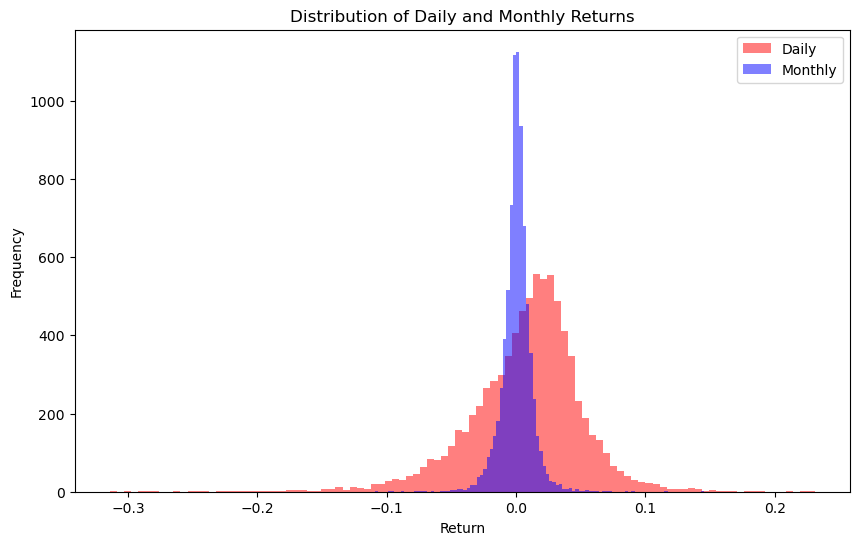

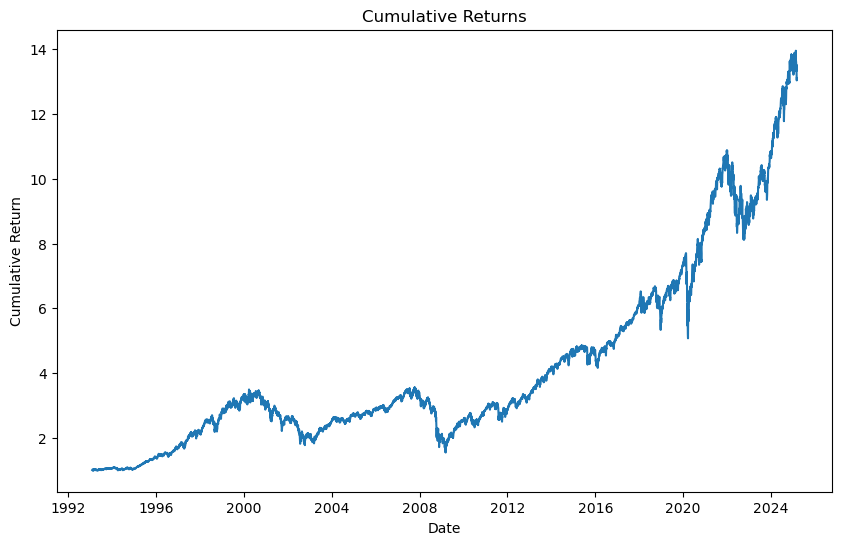

In [3]:
# Use SPY for testing
ticker = "SPY"
df = price_data[ticker].copy()

# Calculate daily returns and monthly returns
df['return'] = df['close'].pct_change()
df['monthly_return'] = df['close'].rolling(window=21).apply(lambda x: (x[-1] - x[0]) / x[0])

# Histogram of returns
plt.figure(figsize=(10, 6))
plt.hist(df['monthly_return'], bins=100, color='red', alpha=0.5)
plt.hist(df['return'], bins=100, color='blue', alpha=0.5)
plt.title('Distribution of Daily and Monthly Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.legend(['Daily', 'Monthly'])
plt.show()

# Cumulative returns
plt.figure(figsize=(10, 6))
plt.plot(df.index, (1 + df['return']).cumprod())
plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

## Lagged Returns

Let's see how the future returns are correlated with lagged returns.

### Linear Regression

Slope (Coefficient):    -0.0698
Intercept:              0.0080
R^2:                    0.0049


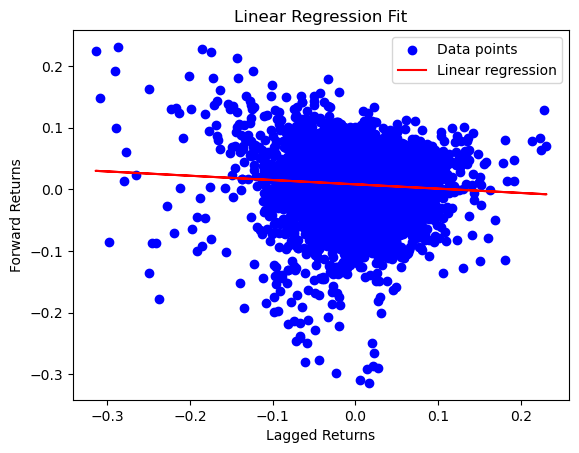

(-0.06980321377146528, 0.007976705120784423, 0.004868015336821352)

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def get_lagged_returns(df, lag_period):
    df = df.copy()
    df['forward_monthly_returns'] = df['close'].rolling(21).apply(lambda x: (x[-1] - x[0]) / x[0]).shift(-21)
    df['lagged_returns'] = df['close'].rolling(lag_period).apply(lambda x: (x[-1] - x[0]) / x[0])
    df = df[['forward_monthly_returns', 'lagged_returns']]
    df.dropna(inplace=True)
    return df

def get_linear_regression(X, y, verbose=True, x_label='X', y_label='y'):
    # Ensure X is a 2D array for sklearn
    X = np.array(X).reshape(-1, 1)
    y = np.array(y)
    
    # Fit the linear regression model
    model = LinearRegression()
    model.fit(X, y)
    
    # Predict y values
    y_pred = model.predict(X)
    
    # Calculate R^2
    r2 = r2_score(y, y_pred)
    
    if verbose:
        # Plot the scatter plot and the regression line
        plt.scatter(X, y, color='blue', label='Data points')
        plt.plot(X, y_pred, color='red', label='Linear regression')
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.title('Linear Regression Fit')
        plt.legend()
        
        # Display the parameters and R^2
        print(f"Slope (Coefficient):    {model.coef_[0]:.4f}")
        print(f"Intercept:              {model.intercept_:.4f}")
        print(f"R^2:                    {r2:.4f}")
        
        plt.show()

    return model.coef_[0], model.intercept_, r2

# Look at correlation with 1 month lagged returns
df_plot = get_lagged_returns(df, 21)

get_linear_regression(df_plot['lagged_returns'], df_plot['forward_monthly_returns'], verbose=True, x_label='Lagged Returns', y_label='Forward Returns')

### Linear Regression for different lookback periods

  0%|          | 0/99 [00:00<?, ?it/s]

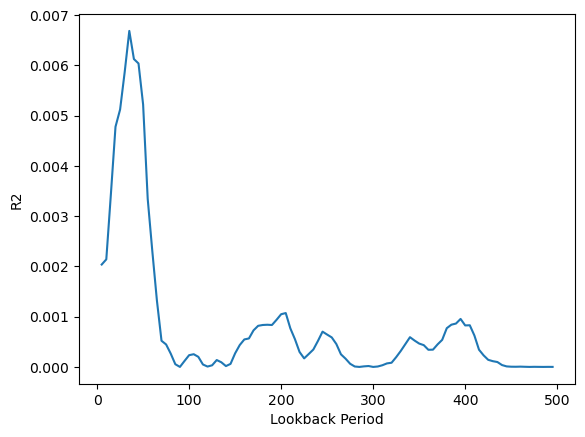

In [5]:
X = range(5, 500, 5)
y = []

for x in tqdm(X):
    df_plot = get_lagged_returns(df, x)
    _, _, r2 = get_linear_regression(
        df_plot['lagged_returns'],
        df_plot['forward_monthly_returns'],
        verbose=False,
    )
    y.append(r2)

plt.plot(X, y)
plt.xlabel('Lookback Period')
plt.ylabel('R2')
plt.show()

Conlusion:
- No good lookback period for linear regression

### Binary Decision

Next we look at setting the problem up as a binary decision: 
- if lagged_returns > 0: long
- if lagged_returns < 0: short

We are looking for the highest difference in returns between the two.

  0%|          | 0/99 [00:00<?, ?it/s]

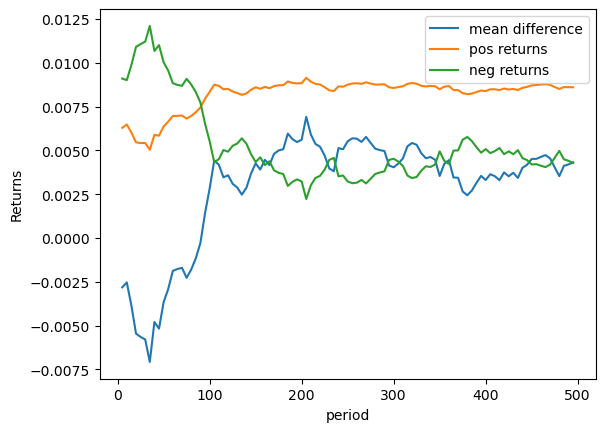

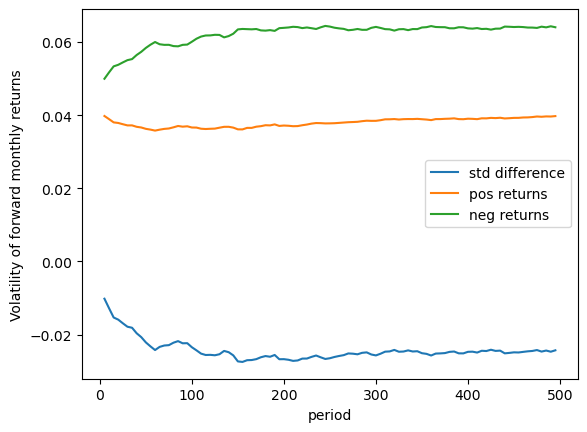

In [6]:
def get_lagged_returns_diff(df, period):
    df = df.copy()
    df = get_lagged_returns(df, period)
    pos_returns = df.loc[df['lagged_returns'] >= 0]['forward_monthly_returns'].to_list()
    neg_returns = df.loc[df['lagged_returns'] < 0]['forward_monthly_returns'].to_list()
    return pos_returns, neg_returns

# Plot mean difference between forward returns from positive and negative lagged returns
X = range(5, 500, 5)
y_returns = []


for period in tqdm(X):
    pos_returns, neg_returns = get_lagged_returns_diff(df, period)
    y_returns.append((pos_returns, neg_returns))

y_mean = [np.mean(pos_returns) - np.mean(neg_returns) for pos_returns, neg_returns in y_returns]
plt.plot(X, y_mean, label='mean difference')
plt.plot(X, [np.mean(y[0]) for y in y_returns], label='pos returns')
plt.plot(X, [np.mean(y[1]) for y in y_returns], label='neg returns')
plt.legend()
plt.xlabel('period')
plt.ylabel('Returns')
plt.show()

y_std = [np.std(pos_returns) - np.std(neg_returns) for pos_returns, neg_returns in y_returns]
plt.plot(X, y_std, label='std difference')
plt.plot(X, [np.std(y[0]) for y in y_returns], label='pos returns')
plt.plot(X, [np.std(y[1]) for y in y_returns], label='neg returns')
plt.legend()
plt.xlabel('period')
plt.ylabel('Volatility of forward monthly returns')
plt.show()



Analysis:
- Mean forward monthly returns are always positive for all lookback periods. We are not directly making returns by shorting when the lagged returns are negative.
- Mean forward monthly returns when lagged returns are positive remain approximately constant.
- Mean forward monthly returns when lagged returns are negative decrease as the lookback period increases.
- The mean difference increases as the lookback period increases, reach a maxima at ~ 250 days.
- Volatility of forward monthly returns show a consistent difference. When lagged returns are negative, the volatility of forward monthly returns is higher.
    - Returns from the strategy may come from volatility reasons, i.e. we avoid highly volatile periods by reducing position size when lagged returns are negative.
    - This suggests that me should reduce position size, rather than short the asset when lagged returns are negative.
    - This also suggests that the strategy may be long volatility. We may out-perform the index when volatility rises by avoiding highly volatile periods.

### Performance across asset history

Look at how the forward monthly returns vary across the history of the asset.

  0%|          | 0/7 [00:00<?, ?it/s]

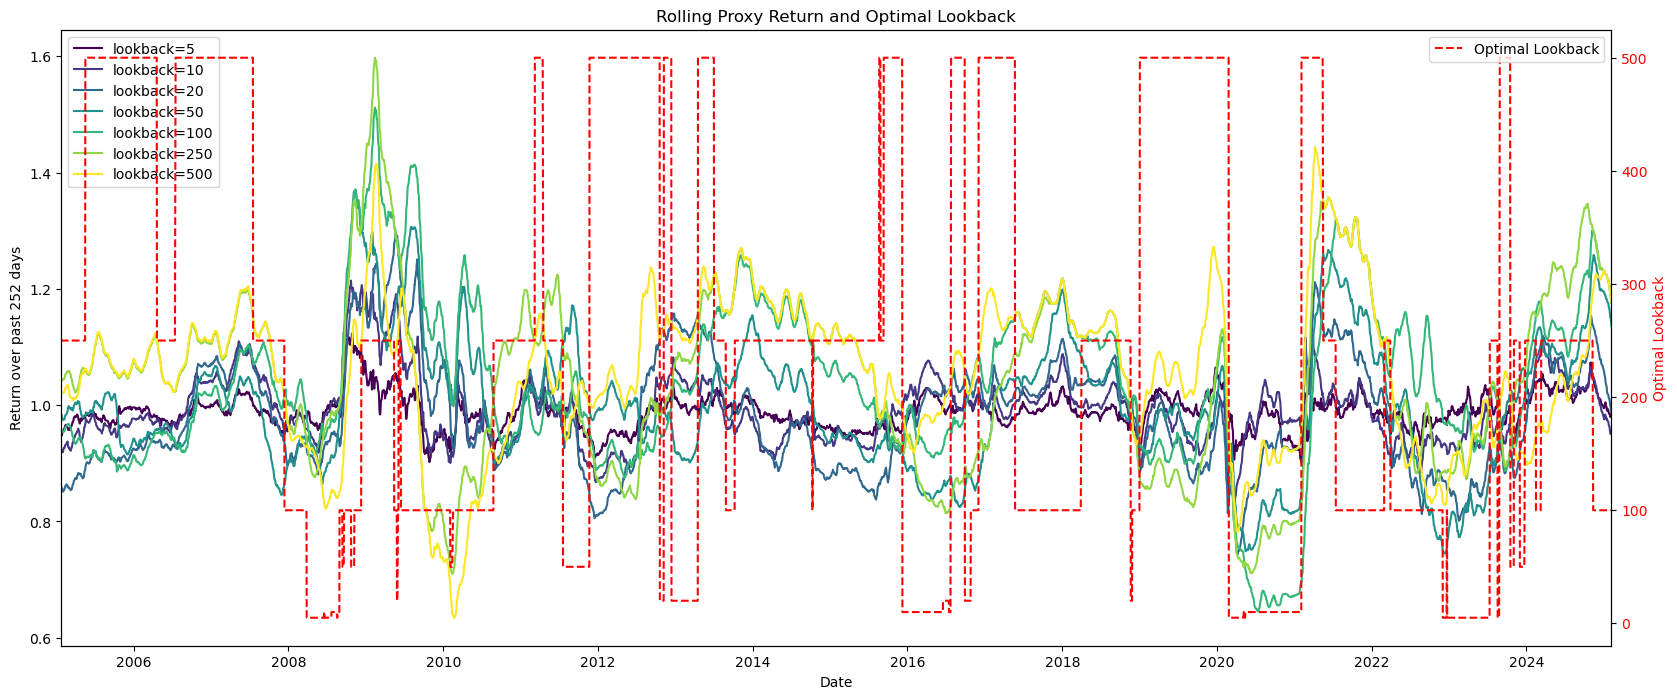

In [15]:
# Define lookback periods
X = [5, 10, 20, 50, 100, 250, 500]
df_best_lookback = pd.DataFrame()

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(20, 8))

# Use Viridis colormap for the rolling_proxy_return plots
colors = plt.cm.viridis(np.linspace(0, 1, len(X)))

# Plot rolling_proxy_return for each lookback period
for period, color in zip(tqdm(X), colors):
    df_plot = get_lagged_returns(df, period)
    df_plot['proxy_return'] = (df_plot['forward_monthly_returns'] * (df_plot['lagged_returns'].apply(lambda x: 1 if x >= 0 else -1)) + 1) ** (1 / 21)
    df_plot['rolling_proxy_return'] = df_plot['proxy_return'].rolling(252).apply(lambda x: np.prod(x))
    ax1.plot(df_plot.index, df_plot['rolling_proxy_return'], label=f'lookback={period}', color=color)

    df_best_lookback[period] = df_plot['rolling_proxy_return']

# Set limits and labels for the primary y-axis
ax1.set_xlim(df_plot.index[2520], df_plot.index[-1])
ax1.set_xlabel('Date')
ax1.set_ylabel('Return over past 252 days', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.legend(loc='upper left')

# Create a secondary y-axis for the optimal lookback
ax2 = ax1.twinx()

# Plot optimal lookback on the secondary y-axis
df_best_lookback.dropna(inplace=True)
df_best_lookback['optimal_lookback'] = df_best_lookback.idxmax(axis=1)
ax2.plot(df_best_lookback.index, df_best_lookback['optimal_lookback'], label='Optimal Lookback', color='red', linestyle='--')

# Set limits and labels for the secondary y-axis
ax2.set_ylabel('Optimal Lookback', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

# Title and show
plt.title('Rolling Proxy Return and Optimal Lookback')
plt.show()

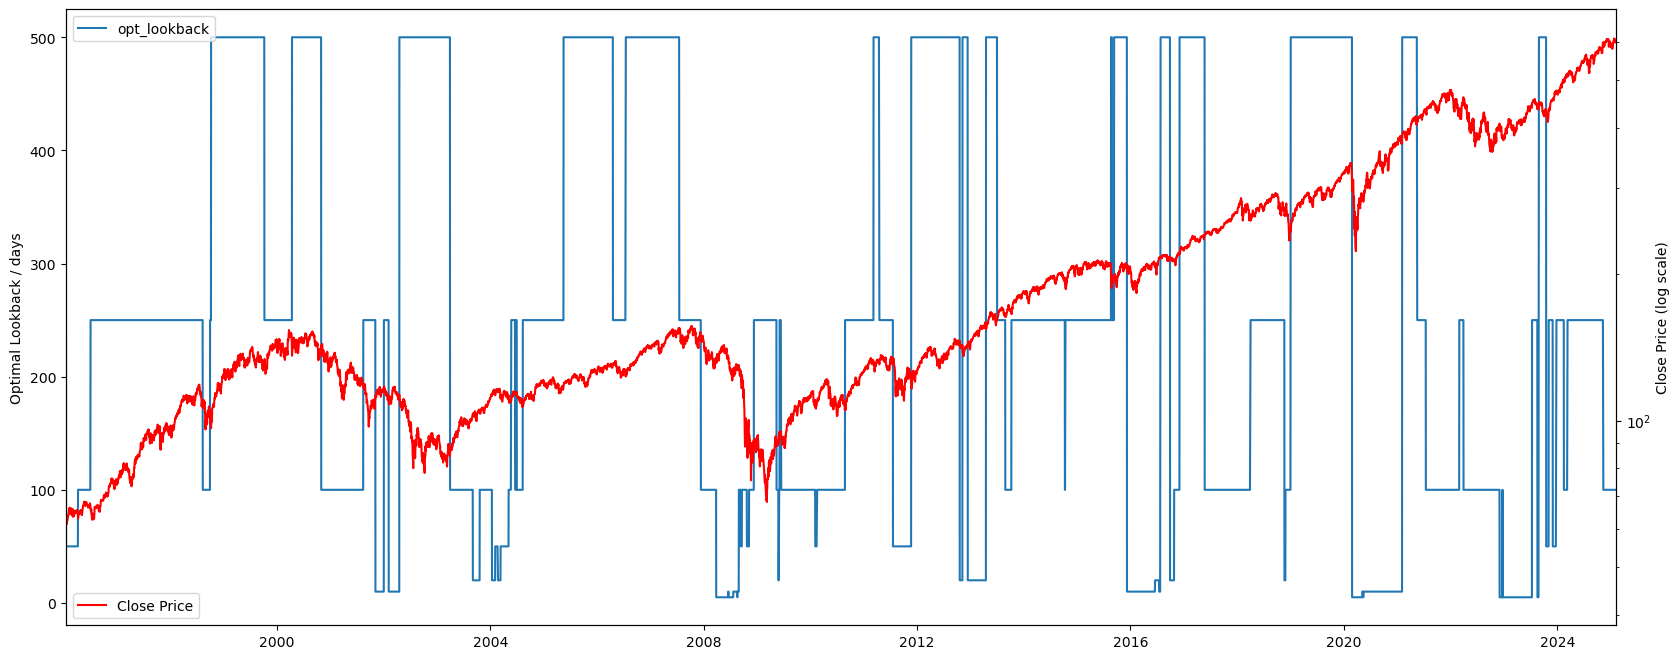

In [26]:
# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(20, 8))
ax1.plot(df_best_lookback.index, df_best_lookback['optimal_lookback'], label='opt_lookback')
ax1.set_xlim(df_best_lookback.index[0], df_best_lookback.index[-1])
ax1.legend(loc='upper left')
ax1.set_ylabel('Optimal Lookback / days')
ax2 = ax1.twinx()
ax2.plot(df.index, df['close'], label='Close Price', color='red')
ax2.set_yscale('log')
ax2.legend(loc='lower left')
ax2.set_ylabel('Close Price (log scale)')
plt.xlabel('Date')
plt.show()

Analysis:
- Optimal lookback period varies across history.
- Optimal lookback period remains stable for some time (sometimes up to a year)
- Optimal lookback period is higher (500 days) and more stable when market is less volatile.
- Optimal lookback period is lower and changes more quickly when market is more volatile (e.g. 2008, 2020)
- There is a possibility of predicting or following the optimal lookback period.

# Buy-Hold Reference

In [ ]:
from strategies.buy_hold import BuyHoldStrategy

def test_buy_hold(ticker, df, verbose=False):
    bt = BackTester({ticker: df})

    # Example 1: Buy and Hold
    bt.add_strategy(BuyHoldStrategy, tickers=[ticker], price_data={ticker: df})
    results = bt.backtest()
    if verbose:
        print("Buy and Hold Results:", {k: v for k, v in results.items() if k != 'returns'})
        bt.plot_results()
    return results['returns']






# Moving Average Crossover

## Reference: long_window=252, short_window=21

In [ ]:
from strategies.trend_following import MovingAverageCrossoverStrategy

def test_moving_average_crossover(ticker, df, long_window, short_window, verbose=False):
    tl = [ticker]
    pda = {ticker: df}
    bt = BackTester(pda)
    bt.add_strategy(MovingAverageCrossoverStrategy, tickers=tl, price_data=pda, short_window=short_window, long_window=long_window, rebalance_period=21)
    results = bt.backtest()
    if verbose:
        print(f"Results for asset [{ticker}]: ")
        for key in results:
            if key == 'returns': continue
            print(f"{key}: {results[key]}")
        bt.plot_results()
    return results['returns']

## Oracle: Optimal long and short windows

In [ ]:
import optuna
from optuna.samplers import TPESampler



def optimize_params(ticker, df, n_trials=100):
    def objective(trial):
        long_window = trial.suggest_int("long_window", 50, 500)
        short_window = trial.suggest_int("short_window", 5, 252)

        if long_window < short_window:
            return -1
        
        tl = [ticker]
        pda = {ticker: df}
        bt = BackTester(pda)
        bt.add_strategy(MovingAverageCrossoverStrategy, tickers=tl, price_data=pda, short_window=short_window, long_window=long_window, rebalance_period=21)
        results = bt.backtest()
        
        return results['sharpe']
        
    study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    return study.best_params


def test_oracle_MA(ticker, df, n_trials=100, verbose=False):
    best_params = optimize_params(ticker, df, n_trials)
    if verbose:
        print(f"Best params: {best_params}")
    results = test_moving_average_crossover(
        ticker=ticker,
        df=df,
        short_window=best_params['short_window'],
        long_window=best_params['long_window'],
        verbose=verbose,
    )
    return results

    
    


# Prior Period Optimization

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
# Initialize TimeSeriesSplit


def test_prior_period_opt(ticker, df, n_splits=5, n_trials=100, verbose=False):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rets = pd.DataFrame()
    # Perform cross-validation splits
    for train_index, test_index in tscv.split(df):
        train = df.iloc[train_index]
        test = df.iloc[test_index]
        if verbose:
            print("Training set size:", len(train), "Testing set size:", len(test))

        # Fit the model on the training set
        best_params = optimize_params(ticker, train, n_trials)

        results = test_moving_average_crossover(
            ticker, 
            test, 
            short_window=best_params['short_window'], 
            long_window=best_params['long_window'],
            verbose=verbose,
        )

        rets = pd.concat([rets, results], axis=0)

    return rets

# Comparison

## SPY

In [ ]:
n_trials = 100

returns_logs = dict()

ticker = "SPY"
df_data = price_data[ticker]
returns_logs['buy_hold'] = test_buy_hold(
    ticker=ticker,
    df=df_data,
    verbose=False,
)
returns_logs['ma_cross_reference'] = test_moving_average_crossover(
    ticker=ticker,
    df=df_data,
    short_window=21,
    long_window=252,
    verbose=False,
)
returns_logs['ma_cross_oracle'] = test_oracle_MA(
    ticker=ticker,
    df=df_data,
    n_trials=100,
    verbose=False,
)

for i in [5, 10]:
    returns_logs[f'ma_cross_prior_opt_{i}'] = test_prior_period_opt(
        ticker=ticker,
        df=df_data,
        n_splits=i,
        n_trials=50,
        verbose=False,
    )




[I 2025-03-02 20:22:13,875] A new study created in memory with name: no-name-6a0a57ae-db2a-44d8-b967-e23e1424a1de


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-03-02 20:22:13,883] Trial 0 finished with value: -1.0 and parameters: {'long_window': 218, 'short_window': 240}. Best is trial 0 with value: -1.0.
[I 2025-03-02 20:22:17,616] Trial 1 finished with value: 0.7087372350647015 and parameters: {'long_window': 380, 'short_window': 153}. Best is trial 1 with value: 0.7087372350647015.
[I 2025-03-02 20:22:21,411] Trial 2 finished with value: 0.6897631825645651 and parameters: {'long_window': 120, 'short_window': 43}. Best is trial 1 with value: 0.7087372350647015.
[I 2025-03-02 20:22:21,414] Trial 3 finished with value: -1.0 and parameters: {'long_window': 76, 'short_window': 219}. Best is trial 1 with value: 0.7087372350647015.
[I 2025-03-02 20:22:25,207] Trial 4 finished with value: 0.7405097468993455 and parameters: {'long_window': 321, 'short_window': 180}. Best is trial 4 with value: 0.7405097468993455.
[I 2025-03-02 20:22:25,209] Trial 5 finished with value: -1.0 and parameters: {'long_window': 59, 'short_window': 245}. Best is t

[I 2025-03-02 20:28:05,982] A new study created in memory with name: no-name-c87837db-bfaf-4b97-9d60-f77ca4f148ce


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-03-02 20:44:54,512] Trial 0 finished with value: -1.0 and parameters: {'long_window': 218, 'short_window': 240}. Best is trial 0 with value: -1.0.
[I 2025-03-02 20:44:57,554] Trial 1 finished with value: 0.7265145507195664 and parameters: {'long_window': 380, 'short_window': 153}. Best is trial 1 with value: 0.7265145507195664.
[I 2025-03-02 20:45:00,642] Trial 2 finished with value: 0.7123333368278143 and parameters: {'long_window': 120, 'short_window': 43}. Best is trial 1 with value: 0.7265145507195664.
[I 2025-03-02 20:45:00,644] Trial 3 finished with value: -1.0 and parameters: {'long_window': 76, 'short_window': 219}. Best is trial 1 with value: 0.7265145507195664.
[I 2025-03-02 20:45:03,697] Trial 4 finished with value: 0.7539550715500705 and parameters: {'long_window': 321, 'short_window': 180}. Best is trial 4 with value: 0.7539550715500705.
[I 2025-03-02 20:45:03,699] Trial 5 finished with value: -1.0 and parameters: {'long_window': 59, 'short_window': 245}. Best is t

[I 2025-03-02 20:47:18,604] A new study created in memory with name: no-name-a4c34bf1-28cc-45b8-8ffa-6872a78d46f8


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-03-02 20:47:18,611] Trial 0 finished with value: -1.0 and parameters: {'long_window': 218, 'short_window': 240}. Best is trial 0 with value: -1.0.
[I 2025-03-02 20:47:21,997] Trial 1 finished with value: 0.7145515003551968 and parameters: {'long_window': 380, 'short_window': 153}. Best is trial 1 with value: 0.7145515003551968.
[I 2025-03-02 20:47:25,406] Trial 2 finished with value: 0.6628389096241762 and parameters: {'long_window': 120, 'short_window': 43}. Best is trial 1 with value: 0.7145515003551968.
[I 2025-03-02 20:47:25,408] Trial 3 finished with value: -1.0 and parameters: {'long_window': 76, 'short_window': 219}. Best is trial 1 with value: 0.7145515003551968.
[I 2025-03-02 20:47:28,800] Trial 4 finished with value: 0.7507434134870788 and parameters: {'long_window': 321, 'short_window': 180}. Best is trial 4 with value: 0.7507434134870788.
[I 2025-03-02 20:47:28,802] Trial 5 finished with value: -1.0 and parameters: {'long_window': 59, 'short_window': 245}. Best is t

## Results

2000-04-11 00:00:00 2025-02-28 00:00:00
buy_hold
 CAGR: 0.0760
 Volatility: 0.1933
 Sharpe Ratio: 0.3932
ma_cross_reference
 CAGR: 0.0810
 Volatility: 0.1307
 Sharpe Ratio: 0.6193
ma_cross_oracle
 CAGR: 0.0833
 Volatility: 0.1437
 Sharpe Ratio: 0.5796
ma_cross_prior_opt_5
 CAGR: 0.0633
 Volatility: 0.1285
 Sharpe Ratio: 0.4927
ma_cross_prior_opt_10
 CAGR: 0.0545
 Volatility: 0.1427
 Sharpe Ratio: 0.3820


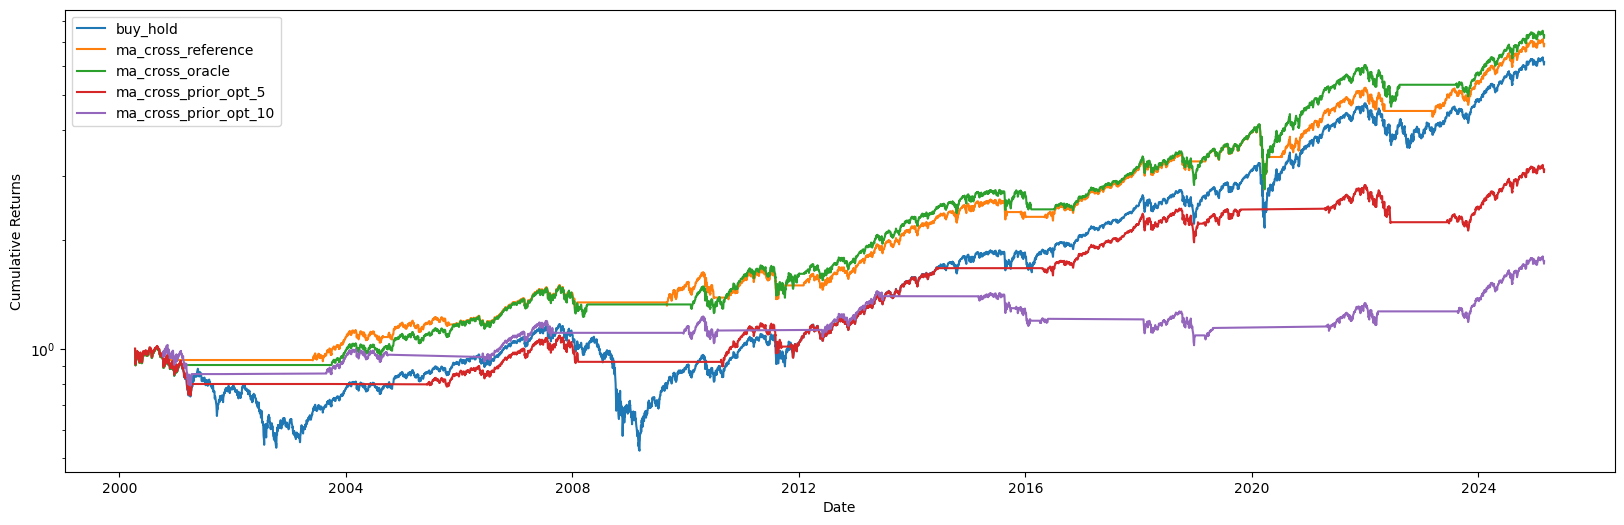

In [ ]:
start_date = None
end_date = None
for method in returns_logs:
    df = returns_logs[method].copy()

    if start_date is None:
        start_date = df.index[0]
    if end_date is None:
        end_date = df.index[-1]
    if df.index[0] > start_date:
        start_date = df.index[0]
    if df.index[-1] < end_date:
        end_date = df.index[-1]

print(start_date, end_date)
plt.figure(figsize=(20, 6))
for method in returns_logs:
    df = returns_logs[method].copy()
    df = df.loc[start_date:end_date]
    df['cumulative_returns'] = (1 + df['returns']).cumprod()
    cagr = (df['cumulative_returns'][-1] ** (252 / len(df))) - 1
    vol = df['returns'].std() * np.sqrt(252)
    sharpe_ratio = cagr / vol

    print(f'{method}\n CAGR: {cagr:.4f}\n Volatility: {vol:.4f}\n Sharpe Ratio: {sharpe_ratio:.4f}')
    
    plt.plot(df['cumulative_returns'], label=f'{method}')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.yscale('log')
plt.legend()
plt.show()

Optimization for long_window and short_window using historical data produces worse results. This suggests that there are regime changes throughout the time series. The parameter are optimized for the previous regime and hence are overfitted and perform worse in the new regime.

# Parameters for prior period optimization

[I 2025-03-02 23:52:20,852] A new study created in memory with name: no-name-f351dd31-410e-43a2-8bb2-aaac51270b69


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-03-02 23:52:20,860] Trial 0 finished with value: -1.0 and parameters: {'long_window': 218, 'short_window': 240}. Best is trial 0 with value: -1.0.
[I 2025-03-02 23:52:21,411] Trial 1 finished with value: 1.8809612392365953 and parameters: {'long_window': 380, 'short_window': 153}. Best is trial 1 with value: 1.8809612392365953.
[I 2025-03-02 23:52:22,015] Trial 2 finished with value: 1.4282293898786864 and parameters: {'long_window': 120, 'short_window': 43}. Best is trial 1 with value: 1.8809612392365953.
[I 2025-03-02 23:52:22,017] Trial 3 finished with value: -1.0 and parameters: {'long_window': 76, 'short_window': 219}. Best is trial 1 with value: 1.8809612392365953.
[I 2025-03-02 23:52:22,566] Trial 4 finished with value: 1.8025861710834405 and parameters: {'long_window': 321, 'short_window': 180}. Best is trial 1 with value: 1.8809612392365953.
[I 2025-03-02 23:52:22,568] Trial 5 finished with value: -1.0 and parameters: {'long_window': 59, 'short_window': 245}. Best is t

[I 2025-03-02 23:52:46,290] A new study created in memory with name: no-name-99186da9-ef48-4200-ad42-f82b8f5bb6d1


[I 2025-03-02 23:52:46,284] Trial 49 finished with value: 1.6717986870045356 and parameters: {'long_window': 231, 'short_window': 143}. Best is trial 42 with value: 2.1688743201021254.


...

[I 2025-03-03 00:13:53,547] A new study created in memory with name: no-name-315758cf-de15-49b6-be24-d78520bb35ed


[I 2025-03-03 00:13:53,540] Trial 49 finished with value: 0.6254677461313783 and parameters: {'long_window': 293, 'short_window': 61}. Best is trial 44 with value: 0.777632463725657.


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-03-03 00:13:53,555] Trial 0 finished with value: -1.0 and parameters: {'long_window': 218, 'short_window': 240}. Best is trial 0 with value: -1.0.
[I 2025-03-03 00:13:53,648] Trial 1 finished with value: 4.026176331580236 and parameters: {'long_window': 380, 'short_window': 153}. Best is trial 1 with value: 4.026176331580236.
[I 2025-03-03 00:13:53,809] Trial 2 finished with value: 0.14106125947219075 and parameters: {'long_window': 120, 'short_window': 43}. Best is trial 1 with value: 4.026176331580236.
[I 2025-03-03 00:13:53,810] Trial 3 finished with value: -1.0 and parameters: {'long_window': 76, 'short_window': 219}. Best is trial 1 with value: 4.026176331580236.
[I 2025-03-03 00:13:53,920] Trial 4 finished with value: 2.435561637548207 and parameters: {'long_window': 321, 'short_window': 180}. Best is trial 1 with value: 4.026176331580236.
[I 2025-03-03 00:13:53,921] Trial 5 finished with value: -1.0 and parameters: {'long_window': 59, 'short_window': 245}. Best is trial 

IndexError: array assignment index out of range

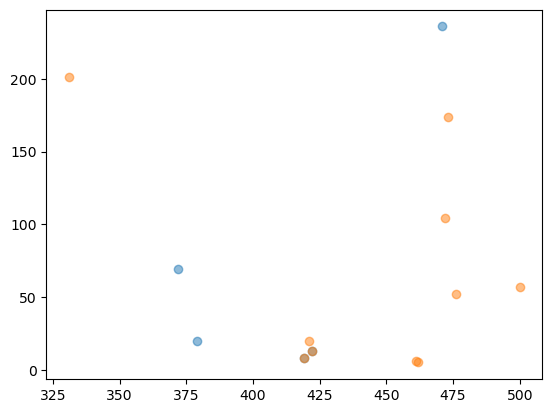

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
# Initialize TimeSeriesSplit


def find_parameters(ticker, df, n_splits=5, n_trials=100, verbose=False):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    df_output = df.copy()
    df_output['short_window'] = 0
    df_output['long_wwindow'] = 0

    params_pairs = []

    # Perform cross-validation splits
    for train_index, test_index in tscv.split(df):
        train = df.iloc[train_index]
        test = df.iloc[test_index]

        # Fit the model on the training set
        best_params = optimize_params(ticker, train, n_trials)

        df_output.loc[df_output.index.isin(train.index), 'short_window'] = best_params['short_window']
        df_output.loc[df_output.index.isin(train.index), 'long_window'] = best_params['long_window']

        params_pairs.append(best_params)
    
    return df_output[['short_window', 'long_window']], params_pairs

ticker = 'SPY'
df_data = price_data[ticker]

for i in [5, 10, 20]:
    df, param_pairs = find_parameters(ticker, df_data, n_splits=i, n_trials=50)

    # plt.plot(df.index, df['short_window'], label='Short Window')
    # plt.plot(df.index, df['long_window'], label='Long Window')
    # plt.title(f'{ticker} - {i} Splits')
    # plt.xlabel('Date')
    # plt.ylabel('Window Size')
    # plt.legend()

    long_windows = [f['long_window'] for f in param_pairs]
    short_windows = [f['short_window'] for f in param_pairs]

    plt.scatter(long_windows, short_windows, alpha=0.5, label=f'{i} Splits')

plt.xlabel('Long Window')
plt.ylabel('Short Window')
plt.legend()
plt.show()

# END